# Predicting Stellar Class — Playground Series S6E6

Classificazione a 3 classi (**GALAXY / QSO / STAR**) su dati di tipo SDSS.
Metrica ufficiale della gara: **balanced accuracy** (le 3 classi pesano uguale).

Struttura: note sui dati → EDA → preprocessing (a prova di errore) → modello → submission.

## Note sulle colonne

- **id** — identificativo, da scartare.
- **alpha, delta** — coordinate sul cielo (*dove*, non *cosa*): geometria della survey, le scartiamo.
- **u, g, r, i, z** — luminosità in 5 filtri (UV → IR). Sono magnitudini: più basso = più luminoso.
- **redshift** — spostamento verso il rosso ≈ distanza. Feature fortissima (STAR ≈ 0, GALAXY/QSO > 0).
- **spectral_type** — tipo spettrale (O B A F G K M, dal caldo/blu al freddo/rosso).
- **galaxy_population** — Red_Sequence (galassie vecchie/rosse) vs Blue_Cloud (giovani/blu).
- **class** — **TARGET**: GALAXY / QSO / STAR. Classi sbilanciate (~65 / 20 / 14 %).

**Feature engineering:** dai 5 filtri costruiamo i 10 *colori* (differenze tra filtri), che
catturano la forma dello spettro indipendentemente dalla luminosità assoluta.

## 1. Esplorazione dei dati (EDA)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("train.csv")
print(train.shape)
train.head()

(577347, 12)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [18]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [19]:
# Distribuzione del target (classi sbilanciate!)
print(train["class"].value_counts())
print(train["class"].value_counts(normalize=True).round(3))

# Valori mancanti per colonna
print("\nValori mancanti:")
print(train.isnull().sum())

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64
class
GALAXY    0.654
QSO       0.203
STAR      0.143
Name: proportion, dtype: float64

Valori mancanti:
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64


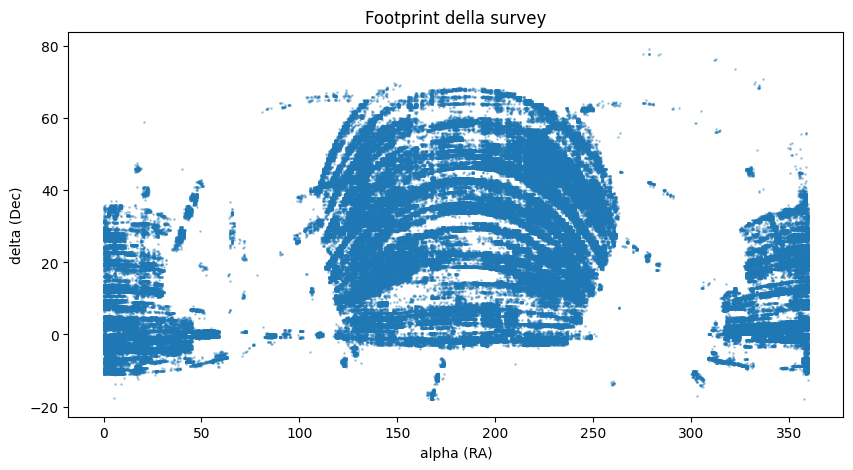

In [20]:
# Footprint della survey: alpha vs delta.
# I vuoti = piano della Via Lattea; le strisce = scansione SDSS.
# alpha/delta sono geometria di osservazione, NON fisica dell'oggetto -> le scarteremo.
plt.figure(figsize=(10, 5))
plt.scatter(train["alpha"], train["delta"], s=1, alpha=0.3)
plt.xlabel("alpha (RA)"); plt.ylabel("delta (Dec)")
plt.title("Footprint della survey")
plt.show()

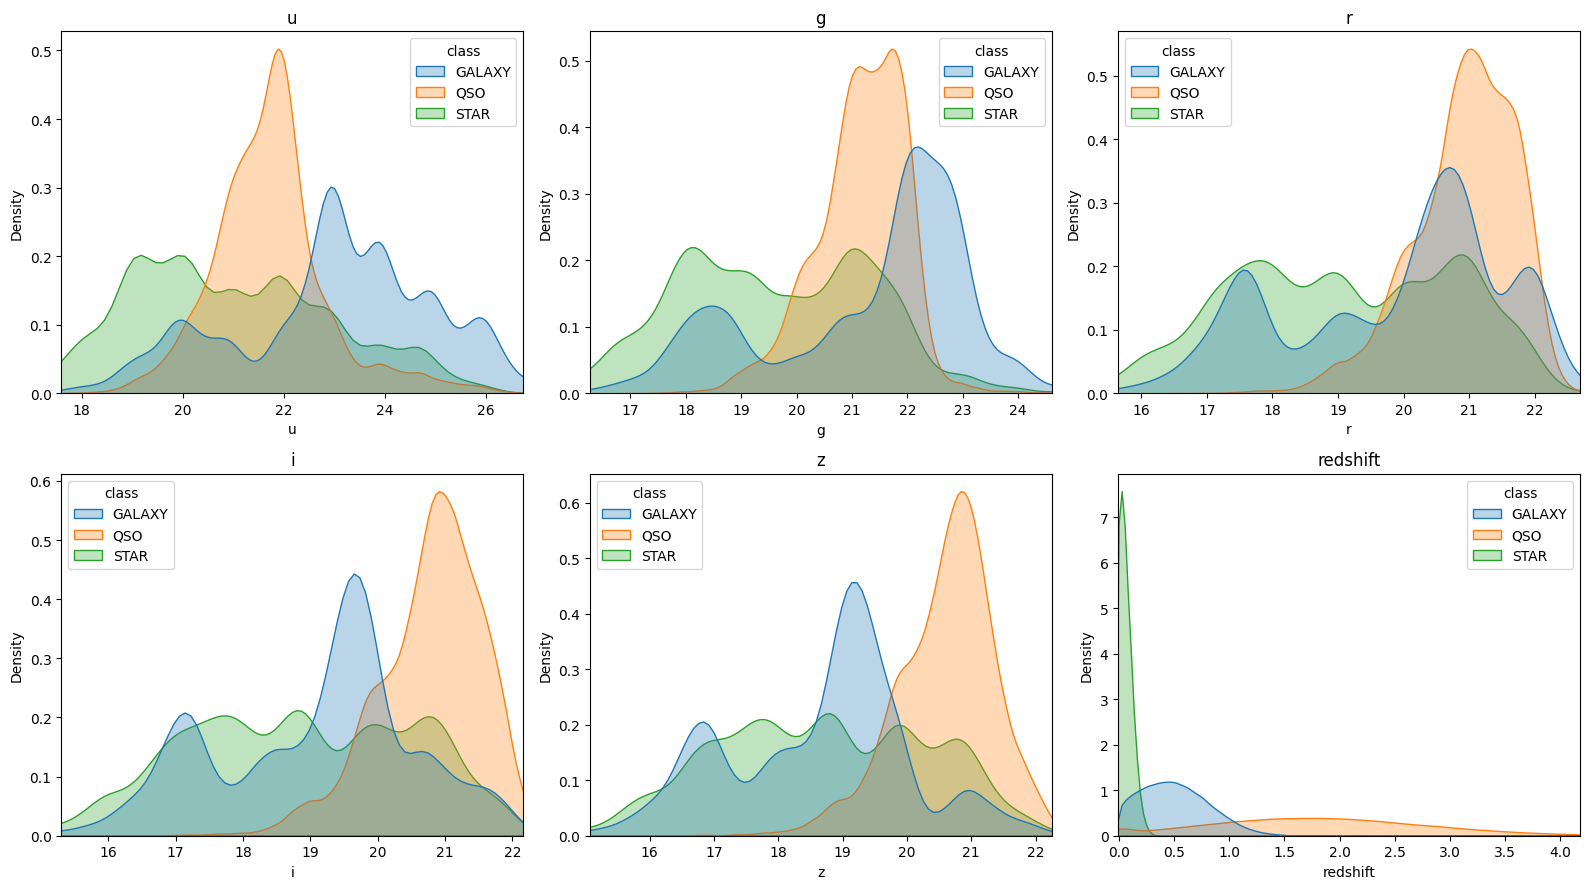

In [21]:
# Distribuzione delle feature numeriche per classe (ogni classe normalizzata a parte)
num_cols = ["u", "g", "r", "i", "z", "redshift"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.kdeplot(data=train, x=col, hue="class", common_norm=False,
                fill=True, alpha=0.3, ax=ax)
    # zoom sul 99% centrale: senza, gli outlier del redshift schiacciano tutto
    ax.set_xlim(train[col].quantile(0.005), train[col].quantile(0.995))
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 2. Preprocessing e feature engineering

Tutto il preprocessing sta in **una sola funzione**, applicata in modo identico a train e test.
È la garanzia che il modello veda le stesse feature nelle due fasi: l'errore che faceva crollare
il punteggio a 0.667 era proprio che i *colori* venivano creati sul train ma non sul test.

In [22]:
from itertools import combinations

FILTERS    = ["u", "g", "r", "i", "z"]
DROP_COLS  = ["alpha", "delta"]                 # geometria della survey, non fisica
CAT_COLS   = ["spectral_type", "galaxy_population"]
CAT_LEVELS = {}                                 # categorie "congelate" dal train

def preprocess(df, fit=False):
    """Stesso identico preprocessing per train e test.
    fit=True solo sul train: memorizza i livelli delle categoriche."""
    df = df.copy()
    # feature engineering: i 10 colori (differenze tra filtri)
    for a, b in combinations(FILTERS, 2):
        df[f"{a}_{b}"] = df[a] - df[b]
    # via le coordinate (geometria, non fisica)
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    # categoriche con livelli identici tra train e test
    for c in CAT_COLS:
        if fit:
            CAT_LEVELS[c] = df[c].astype("category").cat.categories
        df[c] = pd.Categorical(df[c], categories=CAT_LEVELS[c])
    # da aggiungere DENTRO preprocess(), così vale anche per il test
    for c in [f"{a}_{b}" for a, b in combinations(FILTERS, 2)]:
        df[f"{c}_x_z"] = df[c] * df["redshift"]      # colore modulato dal redshift
    df["z_log"] = np.log1p(df["redshift"].clip(lower=0))
    return df

In [23]:
from sklearn.preprocessing import LabelEncoder

X = preprocess(train.drop(columns=["id", "class"]), fit=True)
y = train["class"]

le = LabelEncoder()
y_enc = le.fit_transform(y)                 # GALAXY/QSO/STAR -> 0/1/2

FEATURES = X.columns.tolist()               # ordine canonico delle colonne
print("Feature usate:", FEATURES)

Feature usate: ['u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'u_r', 'u_i', 'u_z', 'g_r', 'g_i', 'g_z', 'r_i', 'r_z', 'i_z', 'u_g_x_z', 'u_r_x_z', 'u_i_x_z', 'u_z_x_z', 'g_r_x_z', 'g_i_x_z', 'g_z_x_z', 'r_i_x_z', 'r_z_x_z', 'i_z_x_z', 'z_log']


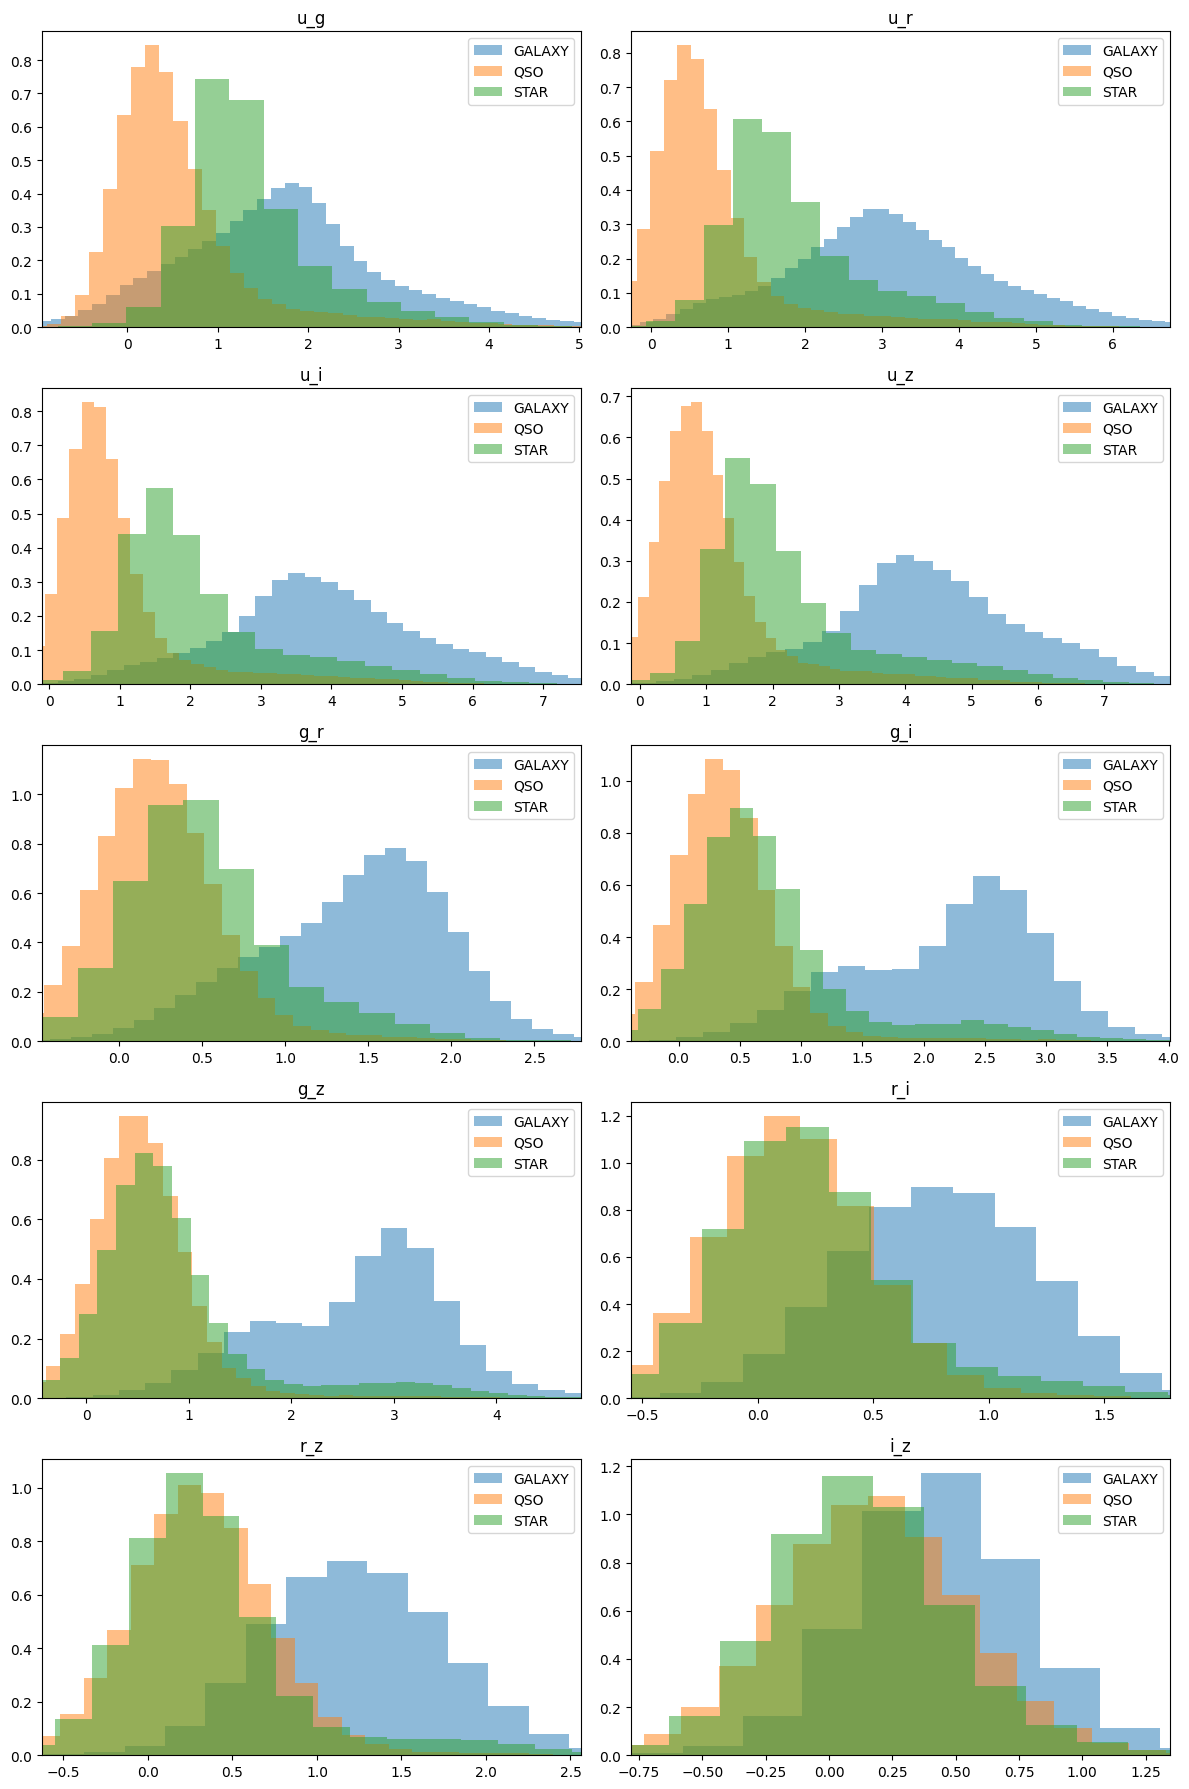

In [24]:
# I 10 colori per classe (creati da preprocess). Mostrano dove le classi si separano.
color_cols = [f"{a}_{b}" for a, b in combinations(FILTERS, 2)]
classes = y.unique()

fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()
for i, col in enumerate(color_cols):
    ax = axes[i]
    for cls in classes:
        sub = X.loc[y == cls, col]
        ax.hist(sub, bins=80, alpha=0.5, label=cls, density=True)
    ax.set_xlim(X[col].quantile(0.005), X[col].quantile(0.995))
    ax.set_title(col); ax.legend()
plt.tight_layout()
plt.show()

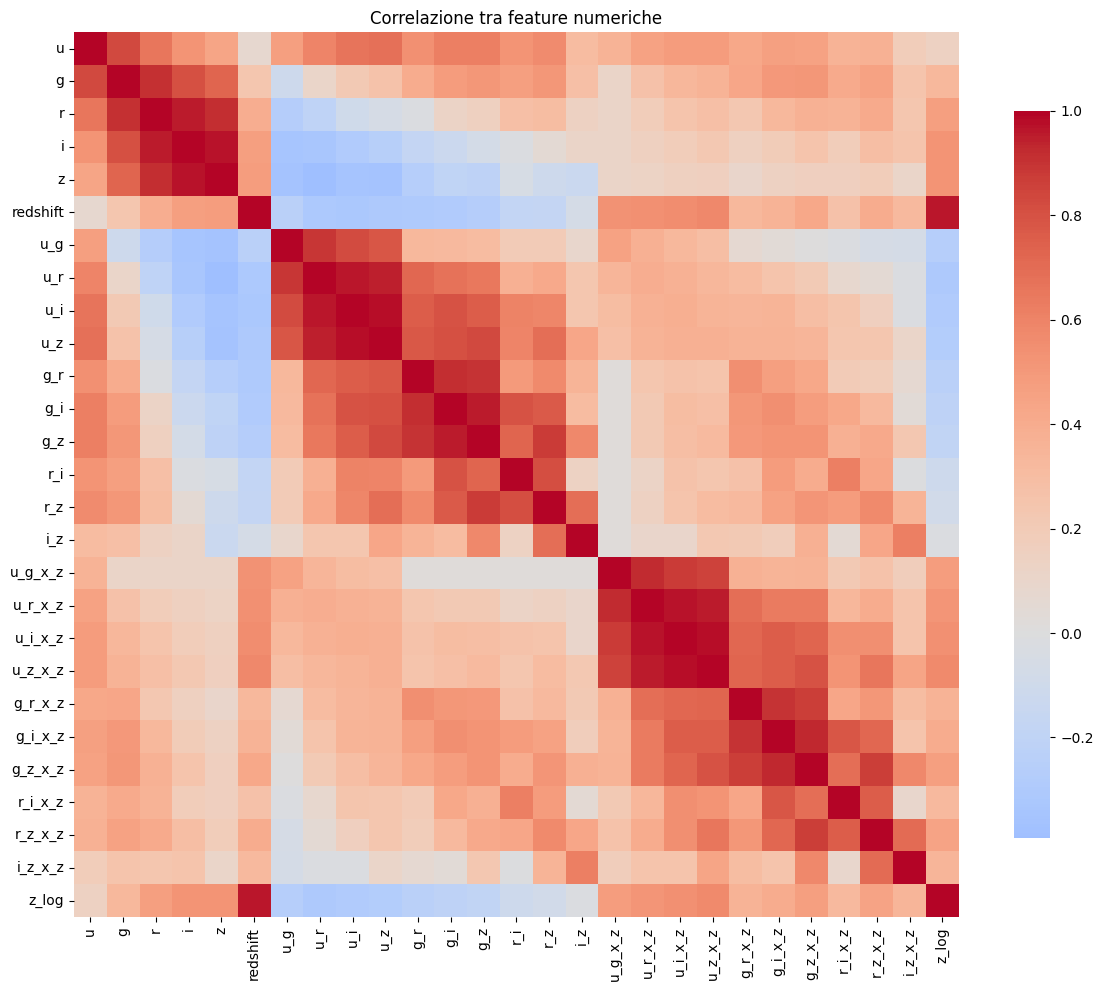

In [25]:
# Correlazione tra le feature numeriche (i colori sono ridondanti tra loro: e' normale)
plt.figure(figsize=(12, 10))
sns.heatmap(X.select_dtypes("number").corr(), cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlazione tra feature numeriche")
plt.tight_layout()
plt.show()

## 3. Modello (XGBoost)

Metrica = balanced accuracy, quindi usiamo `sample_weight` bilanciati per dare lo stesso
peso alle 3 classi nonostante lo sbilanciamento. XGBoost gestisce le categoriche nativamente
(`enable_categorical=True`), così evitiamo del tutto la fragilità del one-hot + reindex.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score, classification_report
from xgboost import XGBClassifier

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# La gara pesa le 3 classi uguali -> diamo piu' peso alle classi rare in addestramento
sw = compute_sample_weight("balanced", y_tr)

model = XGBClassifier(
    n_estimators=600, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.8,
    tree_method="hist", enable_categorical=True,
    eval_metric="mlogloss", n_jobs=-1, random_state=42)
model.fit(X_tr, y_tr, sample_weight=sw)

pred = model.predict(X_val)
print("Balanced accuracy (val):", round(balanced_accuracy_score(y_val, pred), 4))
print(classification_report(y_val, pred, target_names=le.classes_))

Balanced accuracy (val): 0.9509
              precision    recall  f1-score   support

      GALAXY       0.98      0.93      0.96     75496
         QSO       0.94      0.97      0.96     23429
        STAR       0.80      0.95      0.87     16545

    accuracy                           0.94    115470
   macro avg       0.91      0.95      0.93    115470
weighted avg       0.95      0.94      0.94    115470



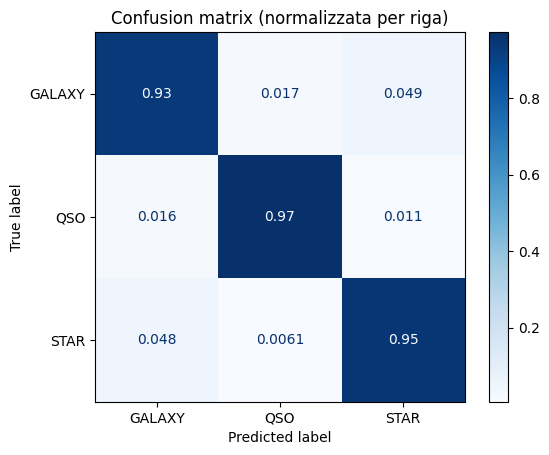

In [28]:
# Dove sbaglia il modello? (la confusione residua e' tipicamente GALAXY <-> QSO)
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_val, pred, display_labels=le.classes_, normalize="true", cmap="Blues")
plt.title("Confusion matrix (normalizzata per riga)")
plt.show()

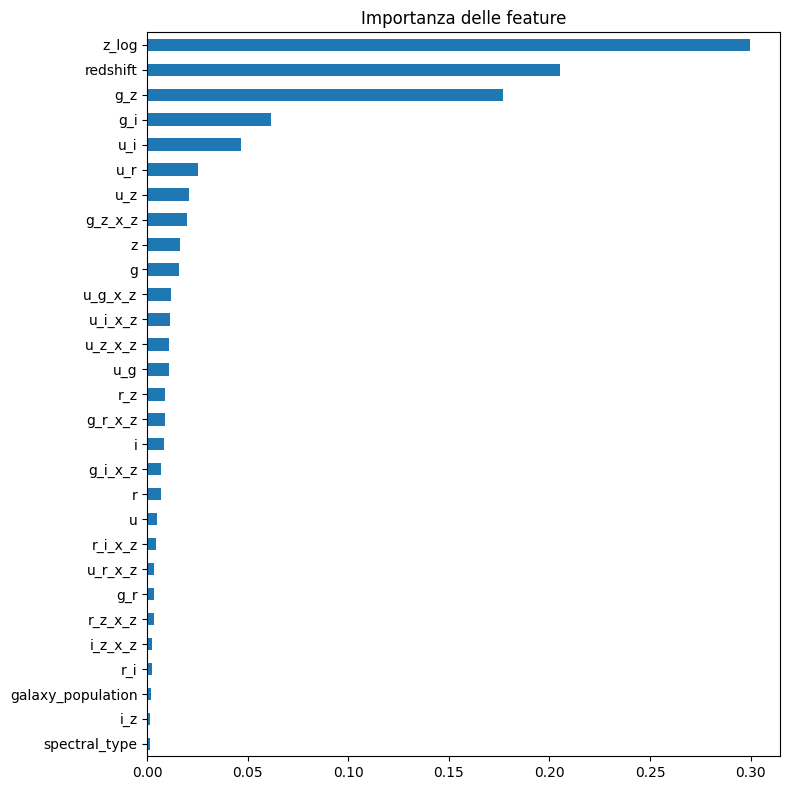

In [29]:
# Quali feature contano di piu' (aspettati redshift in cima)
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", figsize=(8, 8))
plt.title("Importanza delle feature")
plt.tight_layout()
plt.show()

## 4. Submission

Stessa identica funzione `preprocess` del train, più controlli (`assert`) che fanno **fallire**
la cella se qualcosa è disallineato — niente più colonne riempite di zeri in silenzio.

In [30]:
test = pd.read_csv("test.csv")

X_test = preprocess(test.drop(columns=["id"]), fit=False)   # STESSA funzione del train
X_test = X_test[FEATURES]                                   # stesse colonne, stesso ordine

# Se qualcosa e' disallineato, qui ESPLODE invece di sbagliare in silenzio
assert list(X_test.columns) == FEATURES, "Colonne del test disallineate!"
print("Colonne OK:", len(FEATURES))

pred_test = model.predict(X_test)
submission = pd.DataFrame({"id": test["id"], "class": le.inverse_transform(pred_test)})
submission.to_csv("submission.csv", index=False)

# Controllo finale: la distribuzione predetta deve somigliare a quella reale del train
print("\nPredetto sul test:")
print(submission["class"].value_counts(normalize=True).round(3))
print("\nReale nel train:")
print(train["class"].value_counts(normalize=True).round(3))
submission.head()

Colonne OK: 29

Predetto sul test:
class
GALAXY    0.621
QSO       0.209
STAR      0.170
Name: proportion, dtype: float64

Reale nel train:
class
GALAXY    0.654
QSO       0.203
STAR      0.143
Name: proportion, dtype: float64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
